In [25]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import matplotlib.pyplot as plt
from PIL import Image
import torch
import torch.nn as nn
import torch.optim as optim
# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        os.path.join(dirname, filename)

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

In [26]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')


In [ ]:
sample_submission_csv = pd.read_csv('/kaggle/input/datasets/sammywanjohi/spark-2026-breast-lesion-segmentation-challenge/Breast_Ultrasound_Dataset/sample_submission.csv')

In [9]:
sample_submission_csv.head(4)

,image_id,rle_mask
0,sp_test_0051.png,NaN
1,sp_test_0057.png,NaN
2,sp_test_0001.png,NaN
3,sp_test_0058.png,NaN
4,sp_test_0006.png,NaN
5,sp_test_0049.png,NaN
6,sp_test_0017.png,NaN
7,sp_test_0013.png,NaN
8,sp_test_0026.png,NaN
9,sp_test_0060.png,NaN


In [2]:
test_csv = pd.read_csv('/kaggle/input/datasets/sammywanjohi/spark-2026-breast-lesion-segmentation-challenge/Breast_Ultrasound_Dataset/test/test.csv')
train_csv = pd.read_csv('/kaggle/input/datasets/sammywanjohi/spark-2026-breast-lesion-segmentation-challenge/Breast_Ultrasound_Dataset/train/train.csv')
val_csv = pd.read_csv('/kaggle/input/datasets/sammywanjohi/spark-2026-breast-lesion-segmentation-challenge/Breast_Ultrasound_Dataset/val/val.csv')

In [3]:
train_csv.head(4)

,image_id,cls,source,has_lesion
0,sp_train_0001.png,benign,BUSI,1
1,sp_train_0002.png,benign,BUSI,1
2,sp_train_0003.png,benign,BUSI,1
3,sp_train_0004.png,benign,BUSI,1


In [4]:
val_csv.head(4)

,image_id,cls,source,has_lesion
0,sp_val_0001.png,benign,BUSI,1
1,sp_val_0002.png,benign,BUSI,1
2,sp_val_0003.png,benign,BUSI,1
3,sp_val_0004.png,benign,BUSI,1


In [5]:
test_csv.head(4)

,image_id
0,sp_test_0001.png
1,sp_test_0002.png
2,sp_test_0003.png
3,sp_test_0004.png


In [9]:
train_csv['has_lesion'].value_counts()

has_lesion
1    427
Name: count, dtype: int64

In [15]:
# Paths to the directories
train_images_dir = '/kaggle/input/datasets/sammywanjohi/spark-2026-breast-lesion-segmentation-challenge/Breast_Ultrasound_Dataset/train/images/'
train_masks_dir = '/kaggle/input/datasets/sammywanjohi/spark-2026-breast-lesion-segmentation-challenge/Breast_Ultrasound_Dataset/train/masks/'

val_images_dir = '/kaggle/input/datasets/sammywanjohi/spark-2026-breast-lesion-segmentation-challenge/Breast_Ultrasound_Dataset/val/images/'
val_masks_dir = '/kaggle/input/datasets/sammywanjohi/spark-2026-breast-lesion-segmentation-challenge/Breast_Ultrasound_Dataset/val/masks/'

test_images_dir = '/kaggle/input/datasets/sammywanjohi/spark-2026-breast-lesion-segmentation-challenge/Breast_Ultrasound_Dataset/test/images'

In [12]:

def display_images_masks(csv, images_dir, masks_dir, num_samples=5):
    plt.figure(figsize=(10, num_samples * 3))
    for i, row in enumerate(csv.head(num_samples).itertuples()):
        image_path = os.path.join(images_dir, row.image_id)
        mask_path = os.path.join(masks_dir, row.image_id.replace('.png', '_mask.png'))  
        
        # Load images
        image = Image.open(image_path)
        mask = Image.open(mask_path)
        
        # Plot image
        plt.subplot(num_samples, 2, 2*i + 1)
        plt.imshow(image)
        plt.title(f'Image: {row.image_id}')
        plt.axis('off')
        
        # Plot mask
        plt.subplot(num_samples, 2, 2*i + 2)
        plt.imshow(mask, cmap='gray')
        plt.title(f'Mask: {row.image_id}')
        plt.axis('off')
    plt.tight_layout()
    plt.show()


Training samples:


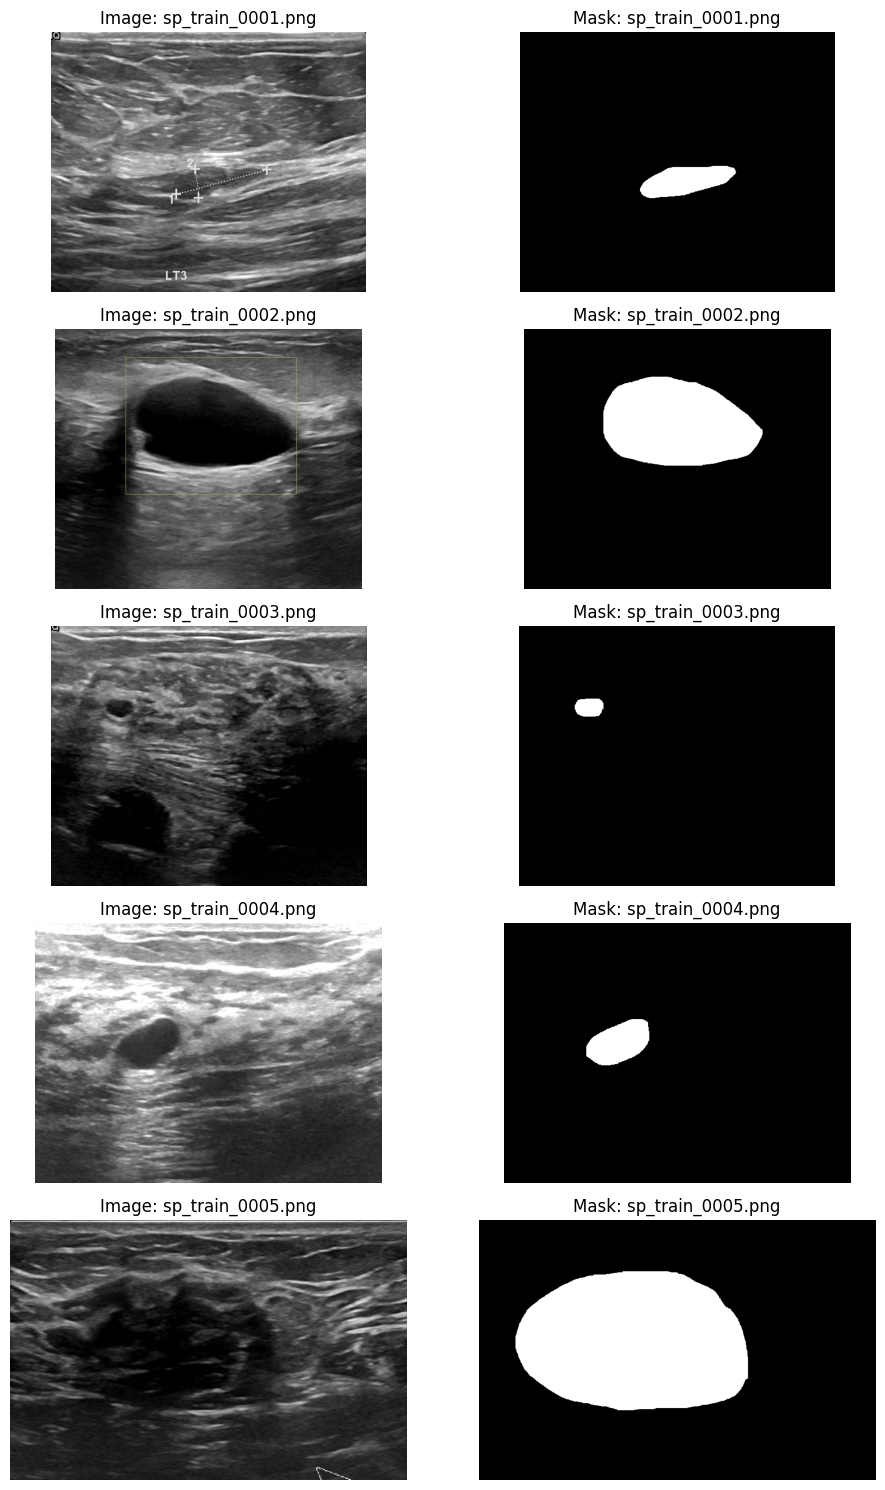

In [13]:
# Display train samples
print("Training samples:")
display_images_masks(train_csv, train_images_dir, train_masks_dir)


Validation samples:


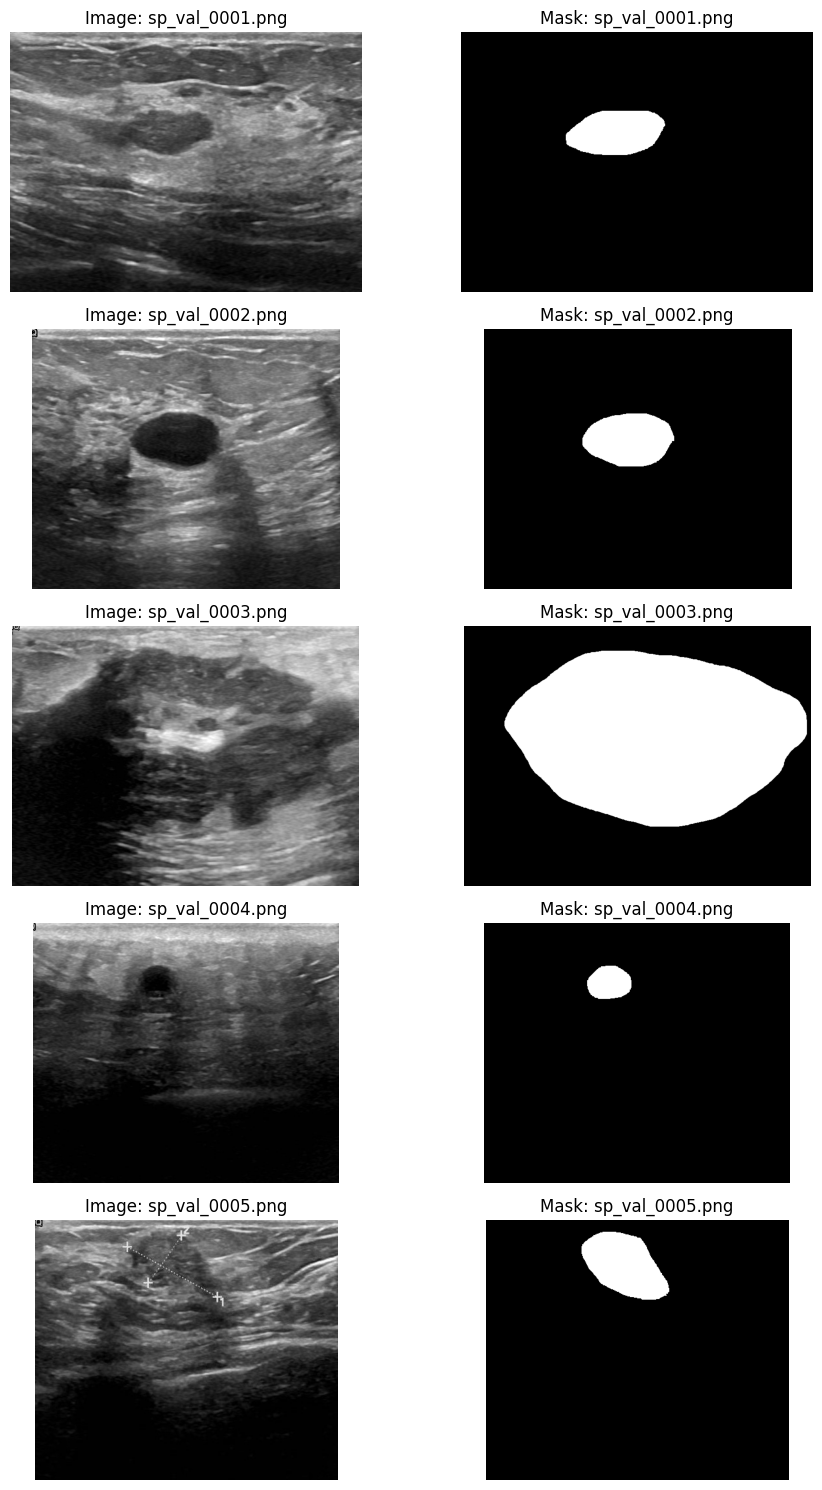

In [14]:

# Display validation samples
print("Validation samples:")
display_images_masks(val_csv, val_images_dir, val_masks_dir)
    

In [ ]:
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms.functional as TF
import random

class BreastSegmentationDataset(Dataset):
    def __init__(self, csv, images_dir, masks_dir=None, img_size=(256, 256), augment=False):
        self.csv = csv.reset_index(drop=True)
        self.images_dir = images_dir
        self.masks_dir = masks_dir
        self.img_size = img_size
        self.augment = augment

    def __len__(self):
        return len(self.csv)

    def __getitem__(self, idx):
        row = self.csv.iloc[idx]
        
        img_path = os.path.join(self.images_dir, row.image_id)
        image = Image.open(img_path).convert('RGB').resize(self.img_size)

        image = np.array(image) / 255.0

        if self.masks_dir:
            mask_path = os.path.join(
                self.masks_dir,
                row.image_id.replace('.png', '_mask.png')
            )
            mask = Image.open(mask_path).convert('L').resize(self.img_size)
            mask = np.array(mask)
            mask = (mask > 128).astype(np.float32)
        else:
            mask = None

        # -------- AUGMENTATION (CRITICAL: SAME TRANSFORM) --------
        if self.augment:
            if random.random() > 0.5:
                image = np.fliplr(image).copy()
                if mask is not None:
                    mask = np.fliplr(mask).copy()

            if random.random() > 0.5:
                image = np.flipud(image).copy()
                if mask is not None:
                    mask = np.flipud(mask).copy()

            # Random rotation (90° multiples → no interpolation artifacts)
            k = random.randint(0, 3)
            image = np.rot90(image, k).copy()
            if mask is not None:
                mask = np.rot90(mask, k).copy()

        # Convert to tensor
        image = torch.tensor(image, dtype=torch.float32).permute(2, 0, 1)

        if mask is not None:
            mask = torch.tensor(mask, dtype=torch.float32).unsqueeze(0)
            return image, mask

        return image

In [18]:
# Create datasets
train_dataset = BreastSegmentationDataset(
    train_csv,
    train_images_dir,
    train_masks_dir,
    augment=True
)

val_dataset = BreastSegmentationDataset(
    val_csv,
    val_images_dir,
    val_masks_dir,
    augment=False
)

test_dataset = BreastSegmentationDataset(
    test_csv,
    test_images_dir,
    masks_dir=None,
    augment=False
)

# Create loaders
train_loader = DataLoader(train_dataset, batch_size=8, shuffle=True, num_workers=2, pin_memory=True)
val_loader   = DataLoader(val_dataset, batch_size=8, shuffle=False, num_workers=2)
test_loader  = DataLoader(test_dataset, batch_size=8, shuffle=False)

In [ ]:
def dice_loss(pred, target, smooth=1e-6):
    pred = torch.sigmoid(pred)
    intersection = (pred * target).sum(dim=(2,3))
    union = pred.sum(dim=(2,3)) + target.sum(dim=(2,3))
    dice = (2. * intersection + smooth) / (union + smooth)
    return 1 - dice.mean()

class BCEDiceLoss(nn.Module):
    def __init__(self):
        super().__init__()
        self.bce = nn.BCEWithLogitsLoss()

    def forward(self, pred, target):
        return self.bce(pred, target) + dice_loss(pred, target)

criterion = BCEDiceLoss()

In [ ]:
def validate(model, loader, criterion):
    model.eval()
    val_loss = 0

    with torch.no_grad():
        for images, masks in loader:
            images = images.to(device)
            masks = masks.to(device)

            outputs = model(images)
            loss = criterion(outputs, masks)
            val_loss += loss.item()

    return val_loss / len(loader)

In [23]:
class DoubleConv(nn.Module):
    def __init__(self, in_channels, out_channels):
        super(DoubleConv, self).__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_channels, out_channels, kernel_size=3, padding=1),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True)
        )

    def forward(self, x):
        return self.conv(x)

class UNet(nn.Module):
    def __init__(self, in_channels=3, out_channels=1, features=[64, 128, 256, 512]):
        super(UNet, self).__init__()
        self.encoder = nn.ModuleList()
        self.pool = nn.MaxPool2d(kernel_size=2, stride=2)

        # Encoder part
        for feature in features:
            self.encoder.append(DoubleConv(in_channels, feature))
            in_channels = feature

        # Decoder part
        self.upconvs = nn.ModuleList()
        self.upconvs_double = nn.ModuleList()

        for feature in reversed(features):
            self.upconvs.append(nn.ConvTranspose2d(feature*2 if feature != features[-1] else feature, feature, kernel_size=2, stride=2))
            self.upconvs_double.append(DoubleConv(feature*2, feature))

        self.bottleneck = DoubleConv(features[-1], features[-1]*2)
        self.final_conv = nn.Conv2d(features[0], out_channels, kernel_size=1)

    def forward(self, x):
        skip_connections = []

        # Encoder pathway
        for encode in self.encoder:
            x = encode(x)
            skip_connections.append(x)
            x = self.pool(x)

        x = self.bottleneck(x)
        skip_connections = skip_connections[::-1]

        # Decoder pathway
        for idx in range(len(self.upconvs)):
            x = self.upconvs[idx](x)
            skip_connection = skip_connections[idx]
            if x.shape != skip_connection.shape:
                x = nn.functional.interpolate(x, size=skip_connection.shape[2:])
            x = torch.cat((skip_connection, x), dim=1)
            x = self.upconvs_double[idx](x)

        return self.final_conv(x)



In [24]:
# Example usage:
model = UNet(in_channels=3, out_channels=1)
print(model)

UNet(
  (encoder): ModuleList(
    (0): DoubleConv(
      (conv): Sequential(
        (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
        (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (2): ReLU(inplace=True)
        (3): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
        (4): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (5): ReLU(inplace=True)
      )
    )
    (1): DoubleConv(
      (conv): Sequential(
        (0): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
        (1): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (2): ReLU(inplace=True)
        (3): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
        (4): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (5): ReLU(inplace=True)
      )
    )
    (2): DoubleConv(
      